<a href="https://colab.research.google.com/github/MateoGlz/Progra-Analitica-Descriptica-Predictiva/blob/main/_26_Validaci0n_Evaluacion_Seleccion_MateoGL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# fetch dataset
glioma_grading_clinical_and_mutation_features = fetch_ucirepo(id=759)

# data (as pandas dataframes)
X = glioma_grading_clinical_and_mutation_features.data.features
y = glioma_grading_clinical_and_mutation_features.data.targets

# metadata
print(glioma_grading_clinical_and_mutation_features.metadata)

# variable information
print(glioma_grading_clinical_and_mutation_features.variables)


{'uci_id': 759, 'name': 'Glioma Grading Clinical and Mutation Features', 'repository_url': 'https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/759/data.csv', 'abstract': 'Gliomas are the most common primary tumors of the brain. They can be graded as LGG (Lower-Grade Glioma) or GBM (Glioblastoma Multiforme) depending on the histological/imaging criteria. Clinical and molecular/mutation factors are also very crucial for the grading process. Molecular tests are expensive to help accurately diagnose glioma patients.    In this dataset, the most frequently mutated 20 genes and 3 clinical features are considered from TCGA-LGG and TCGA-GBM brain glioma projects.  The prediction task is to determine whether a patient is LGG or GBM with a given clinical and molecular/mutation features. The main objective is to find the optimal subset of mutation genes and clinical features for the glioma grading 

In [2]:
# Información de las variables del dataset
variables_info = glioma_grading_clinical_and_mutation_features.variables
print("=== INFORMACIÓN DE VARIABLES ===")
print(variables_info)

# Filtrar solo las variables features (predictoras)
features_info = variables_info[variables_info['role'] == 'Feature']
print(f"\n=== VARIABLES PREDICTORAS (Features) - {len(features_info)} variables ===")
print(features_info[['name', 'type', 'description']])

# Variable objetivo
target_info = variables_info[variables_info['role'] == 'Target']
print(f"\n=== VARIABLE OBJETIVO (Target) ===")
print(target_info[['name', 'type', 'description']])

# Datos completos
df = pd.concat([X, y], axis=1)
print(f"\n=== DATASET COMPLETO ===")
print(f"Dimensiones: {df.shape}")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Mostrar primeras filas
print("\n=== PRIMERAS 5 FILAS ===")
print(df.head())

# Información de tipos de datos
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

# Estadísticas descriptivas de variables numéricas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas) ===")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[numeric_cols].describe())

# Distribución de variables categóricas
print("\n=== DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ===")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Ver valores faltantes
print("\n=== VALORES FALTANTES ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

=== INFORMACIÓN DE VARIABLES ===
                name     role         type demographic  \
0              Grade   Target  Categorical        None   
1             Gender  Feature  Categorical      Gender   
2   Age_at_diagnosis  Feature   Continuous         Age   
3               Race  Feature  Categorical        Race   
4               IDH1  Feature  Categorical        None   
5               TP53  Feature  Categorical        None   
6               ATRX  Feature  Categorical        None   
7               PTEN  Feature  Categorical        None   
8               EGFR  Feature  Categorical        None   
9                CIC  Feature  Categorical        None   
10             MUC16  Feature  Categorical        None   
11            PIK3CA  Feature  Categorical        None   
12               NF1  Feature  Categorical        None   
13            PIK3R1  Feature  Categorical        None   
14             FUBP1  Feature  Categorical        None   
15               RB1  Feature  Categori

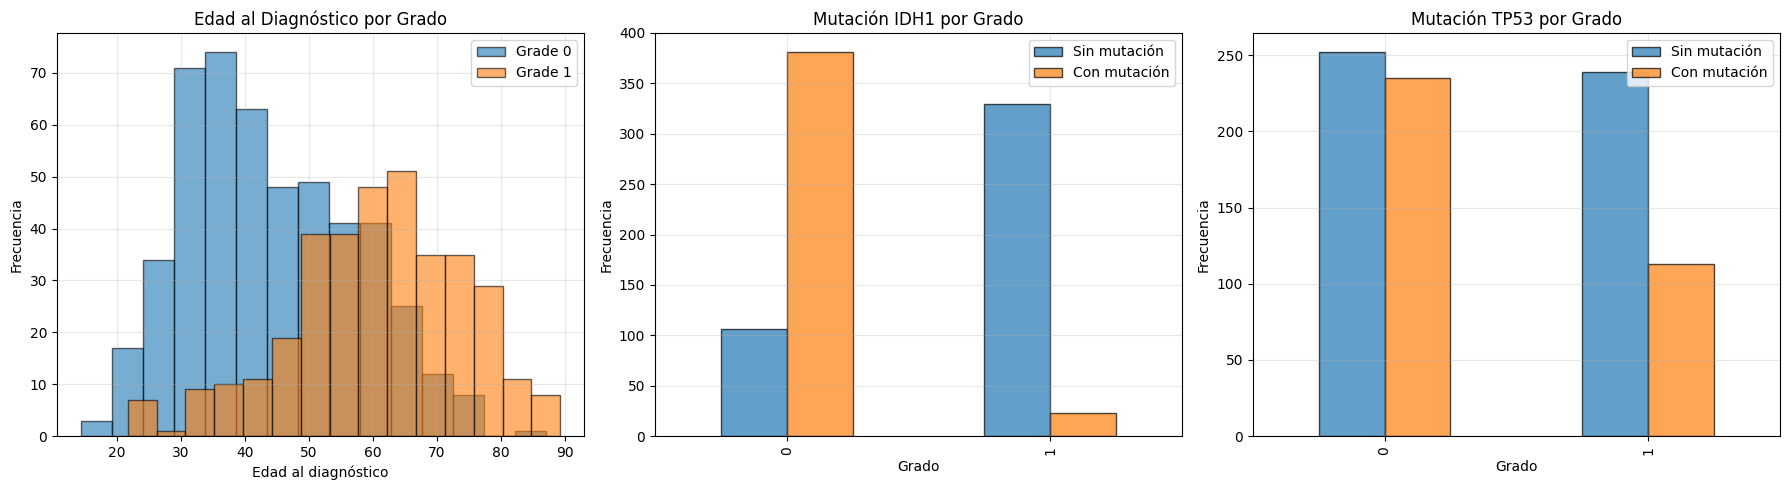

In [3]:
# Histogramas separados por Grade
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age_at_diagnosis por Grade
for grade in df['Grade'].unique():
    subset = df[df['Grade'] == grade]
    axes[0].hist(subset['Age_at_diagnosis'], bins=15, alpha=0.6,
                label=f'Grade {grade}', edgecolor='black')
axes[0].set_xlabel('Edad al diagnóstico')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Edad al Diagnóstico por Grado')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. IDH1 por Grade
idh1_by_grade = pd.crosstab(df['Grade'], df['IDH1'])
idh1_by_grade.plot(kind='bar', ax=axes[1], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Grado')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Mutación IDH1 por Grado')
axes[1].legend(['Sin mutación', 'Con mutación'])
axes[1].grid(True, alpha=0.3)

# 3. TP53 por Grade
tp53_by_grade = pd.crosstab(df['Grade'], df['TP53'])
tp53_by_grade.plot(kind='bar', ax=axes[2], alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Grado')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Mutación TP53 por Grado')
axes[2].legend(['Sin mutación', 'Con mutación'])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

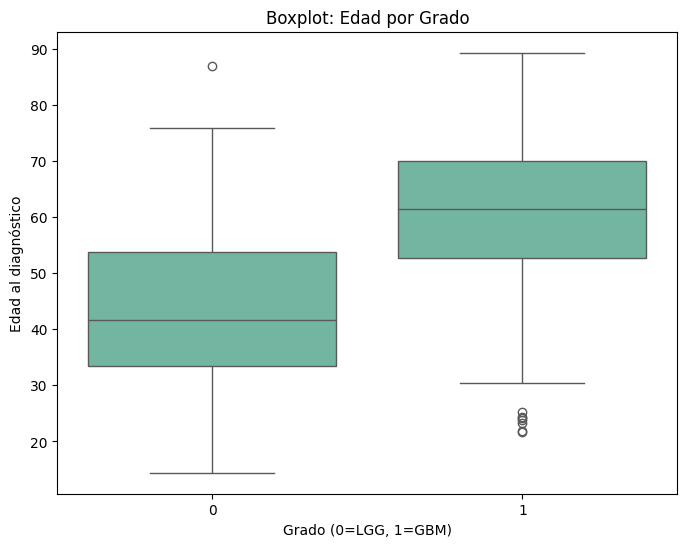

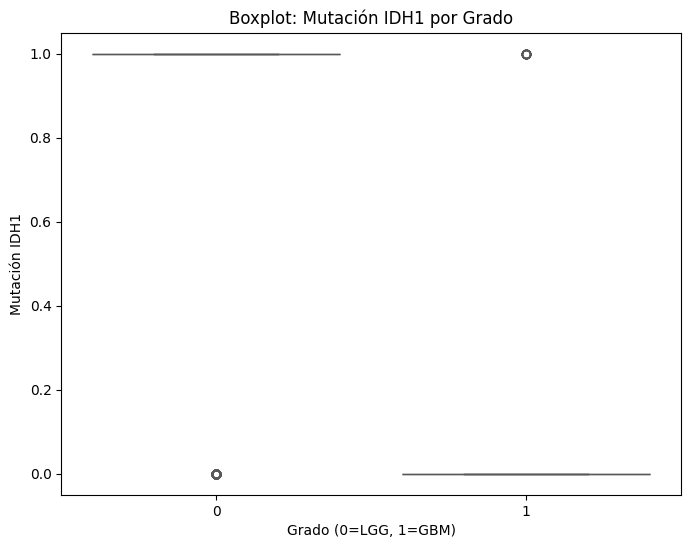

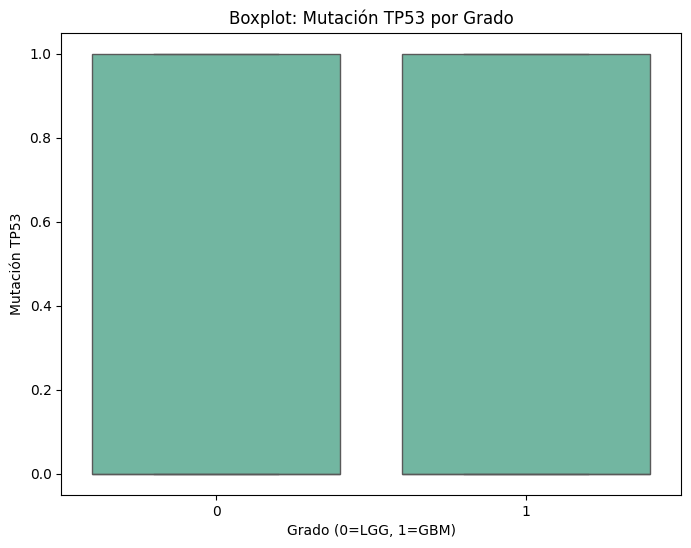

In [4]:
plt.style.use('default')
sns.set_palette("Set2")

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Grade', y='Age_at_diagnosis')
plt.title('Boxplot: Edad por Grado')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Edad al diagnóstico')
plt.show()

# BOXPLOT 2: IDH1 por Grade
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Grade', y='IDH1')
plt.title('Boxplot: Mutación IDH1 por Grado')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Mutación IDH1')
plt.show()

# BOXPLOT 3: TP53 por Grade
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Grade', y='TP53')
plt.title('Boxplot: Mutación TP53 por Grado')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Mutación TP53')
plt.show()

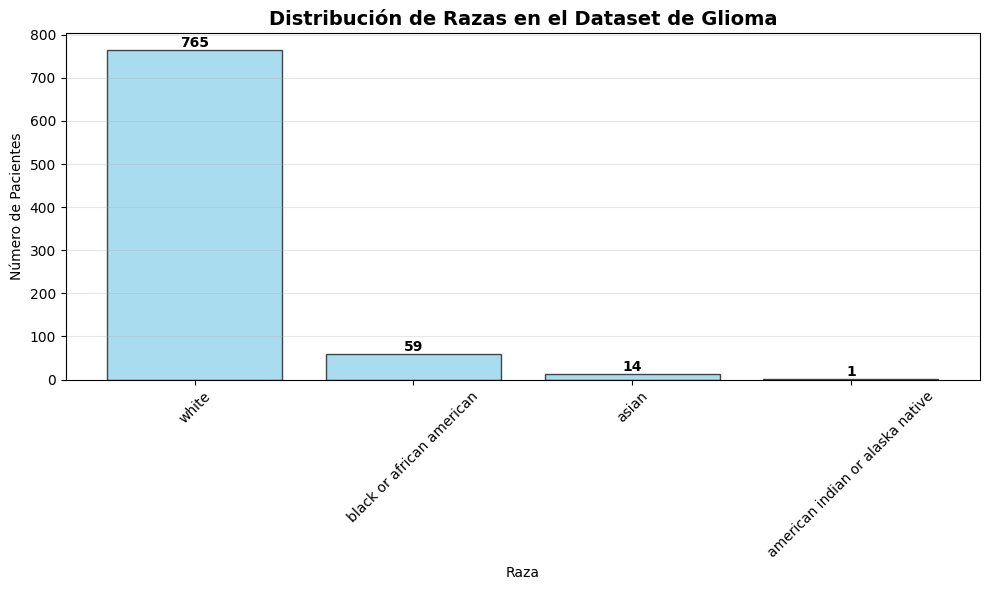

<Figure size 1200x600 with 0 Axes>

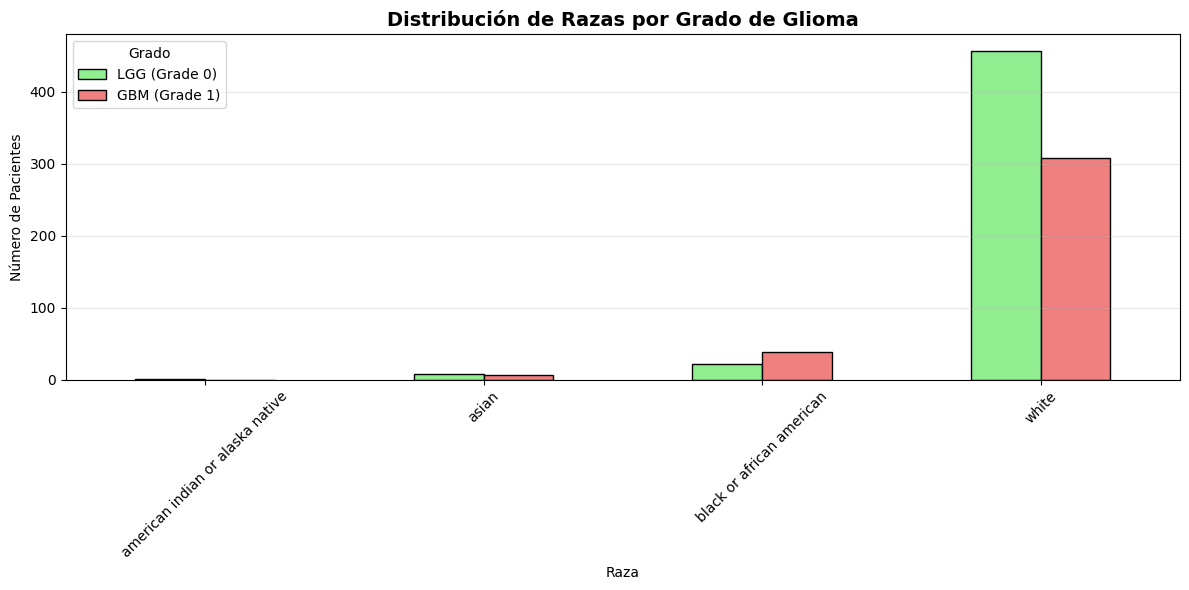

<Figure size 1200x600 with 0 Axes>

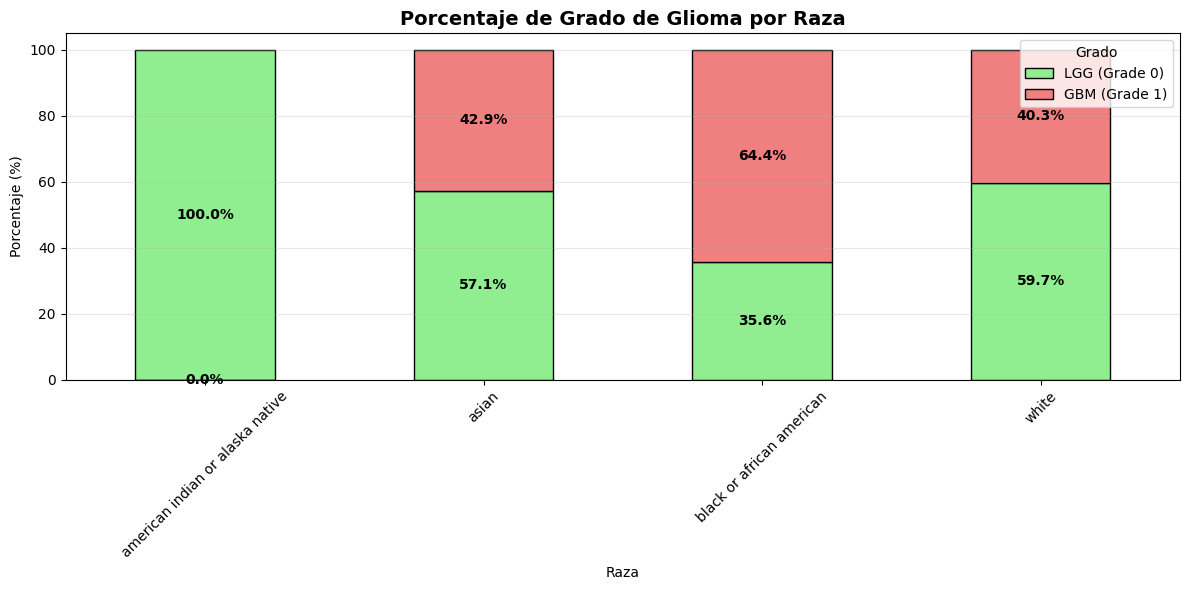

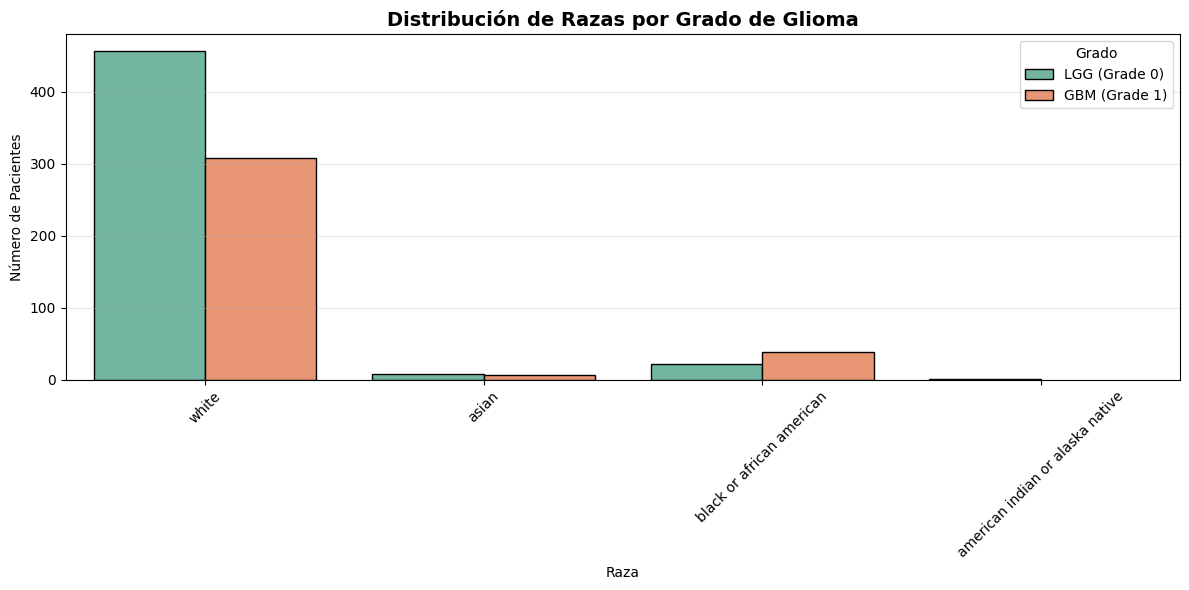

=== ESTADÍSTICAS DE RACE ===

Distribución general:
Race
white                               765
black or african american            59
asian                                14
american indian or alaska native      1
Name: count, dtype: int64

Total de pacientes: 839

Distribución por Grade:
Grade                               0    1
Race                                      
american indian or alaska native    1    0
asian                               8    6
black or african american          21   38
white                             457  308

Porcentajes por Grade:
Grade                                 0     1
Race                                         
american indian or alaska native  100.0   0.0
asian                              57.1  42.9
black or african american          35.6  64.4
white                              59.7  40.3


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('default')
sns.set_palette("pastel")

plt.figure(figsize=(10, 6))
race_counts = df['Race'].value_counts()
bars = plt.bar(race_counts.index, race_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.title('Distribución de Razas en el Dataset de Glioma', fontsize=14, fontweight='bold')
plt.xlabel('Raza')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
race_grade = pd.crosstab(df['Race'], df['Grade'])
race_grade.plot(kind='bar', figsize=(12, 6), color=['lightgreen', 'lightcoral'], edgecolor='black')

plt.title('Distribución de Razas por Grado de Glioma', fontsize=14, fontweight='bold')
plt.xlabel('Raza')
plt.ylabel('Número de Pacientes')
plt.legend(['LGG (Grade 0)', 'GBM (Grade 1)'], title='Grado')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
race_grade_pct = pd.crosstab(df['Race'], df['Grade'], normalize='index') * 100
ax = race_grade_pct.plot(kind='bar', figsize=(12, 6), color=['lightgreen', 'lightcoral'],
                        edgecolor='black', stacked=True)

plt.title('Porcentaje de Grado de Glioma por Raza', fontsize=14, fontweight='bold')
plt.xlabel('Raza')
plt.ylabel('Porcentaje (%)')
plt.legend(['LGG (Grade 0)', 'GBM (Grade 1)'], title='Grado')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Race', hue='Grade', palette='Set2', edgecolor='black')
plt.title('Distribución de Razas por Grado de Glioma', fontsize=14, fontweight='bold')
plt.xlabel('Raza')
plt.ylabel('Número de Pacientes')
plt.legend(['LGG (Grade 0)', 'GBM (Grade 1)'], title='Grado')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("=== ESTADÍSTICAS DE RACE ===")
print("\nDistribución general:")
print(race_counts)
print(f"\nTotal de pacientes: {len(df)}")

print("\nDistribución por Grade:")
print(race_grade)

print("\nPorcentajes por Grade:")
print(race_grade_pct.round(1))

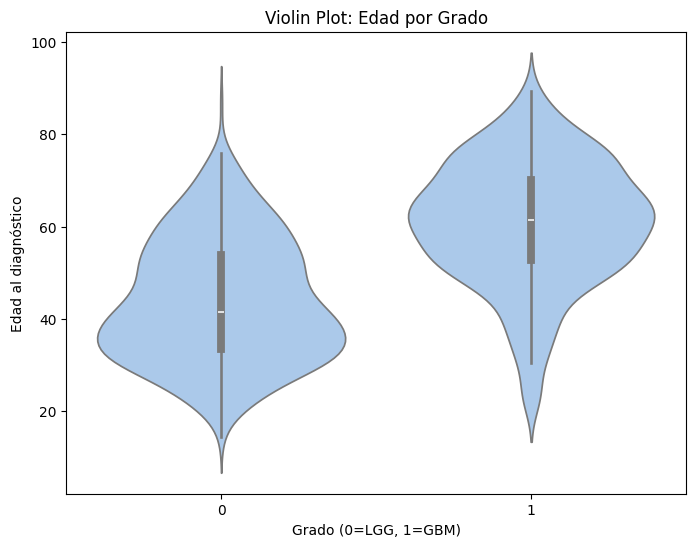

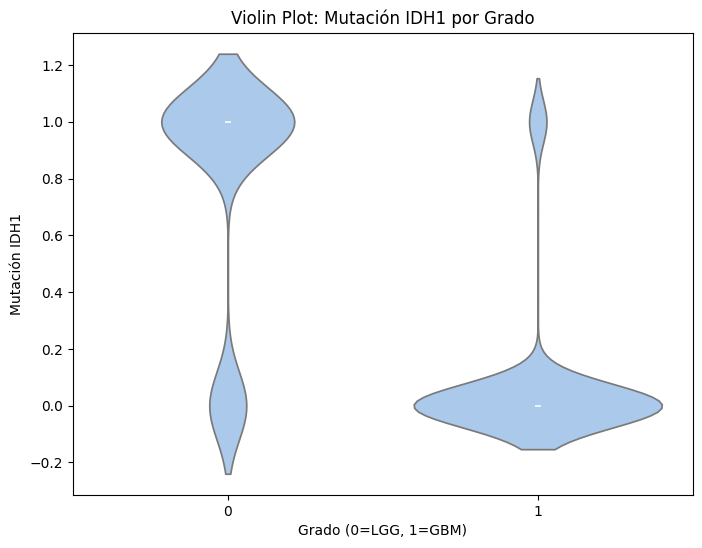

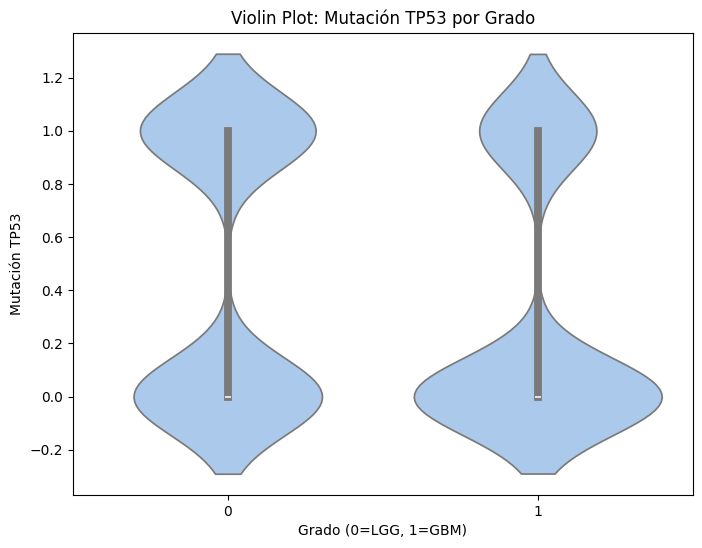

In [6]:
# VIOLIN PLOT 1: Age_at_diagnosis por Grade
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Grade', y='Age_at_diagnosis')
plt.title('Violin Plot: Edad por Grado')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Edad al diagnóstico')
plt.show()

# VIOLIN PLOT 2: IDH1 por Grade
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Grade', y='IDH1')
plt.title('Violin Plot: Mutación IDH1 por Grado')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Mutación IDH1')
plt.show()

# VIOLIN PLOT 3: TP53 por Grade
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Grade', y='TP53')
plt.title('Violin Plot: Mutación TP53 por Grado')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Mutación TP53')
plt.show()

=== VARIABLES NUMÉRICAS INCLUIDAS ===
Total de variables numéricas: 23
Variables: ['Gender', 'Age_at_diagnosis', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA', 'Grade']

=== MATRIZ DE CORRELACIÓN ===
                  Gender  Age_at_diagnosis   IDH1   TP53   ATRX   PTEN   EGFR  \
Gender             1.000            -0.016  0.048  0.002  0.056 -0.032 -0.034   
Age_at_diagnosis  -0.016             1.000 -0.569 -0.316 -0.418  0.259  0.228   
IDH1               0.048            -0.569  1.000  0.341  0.455 -0.395 -0.357   
TP53               0.002            -0.316  0.341  1.000  0.547 -0.068 -0.174   
ATRX               0.056            -0.418  0.455  0.547  1.000 -0.185 -0.160   
PTEN              -0.032             0.259 -0.395 -0.068 -0.185  1.000  0.180   
EGFR              -0.034             0.228 -0.357 -0.174 -0.160  0.180  1.000   
CIC                0.061  

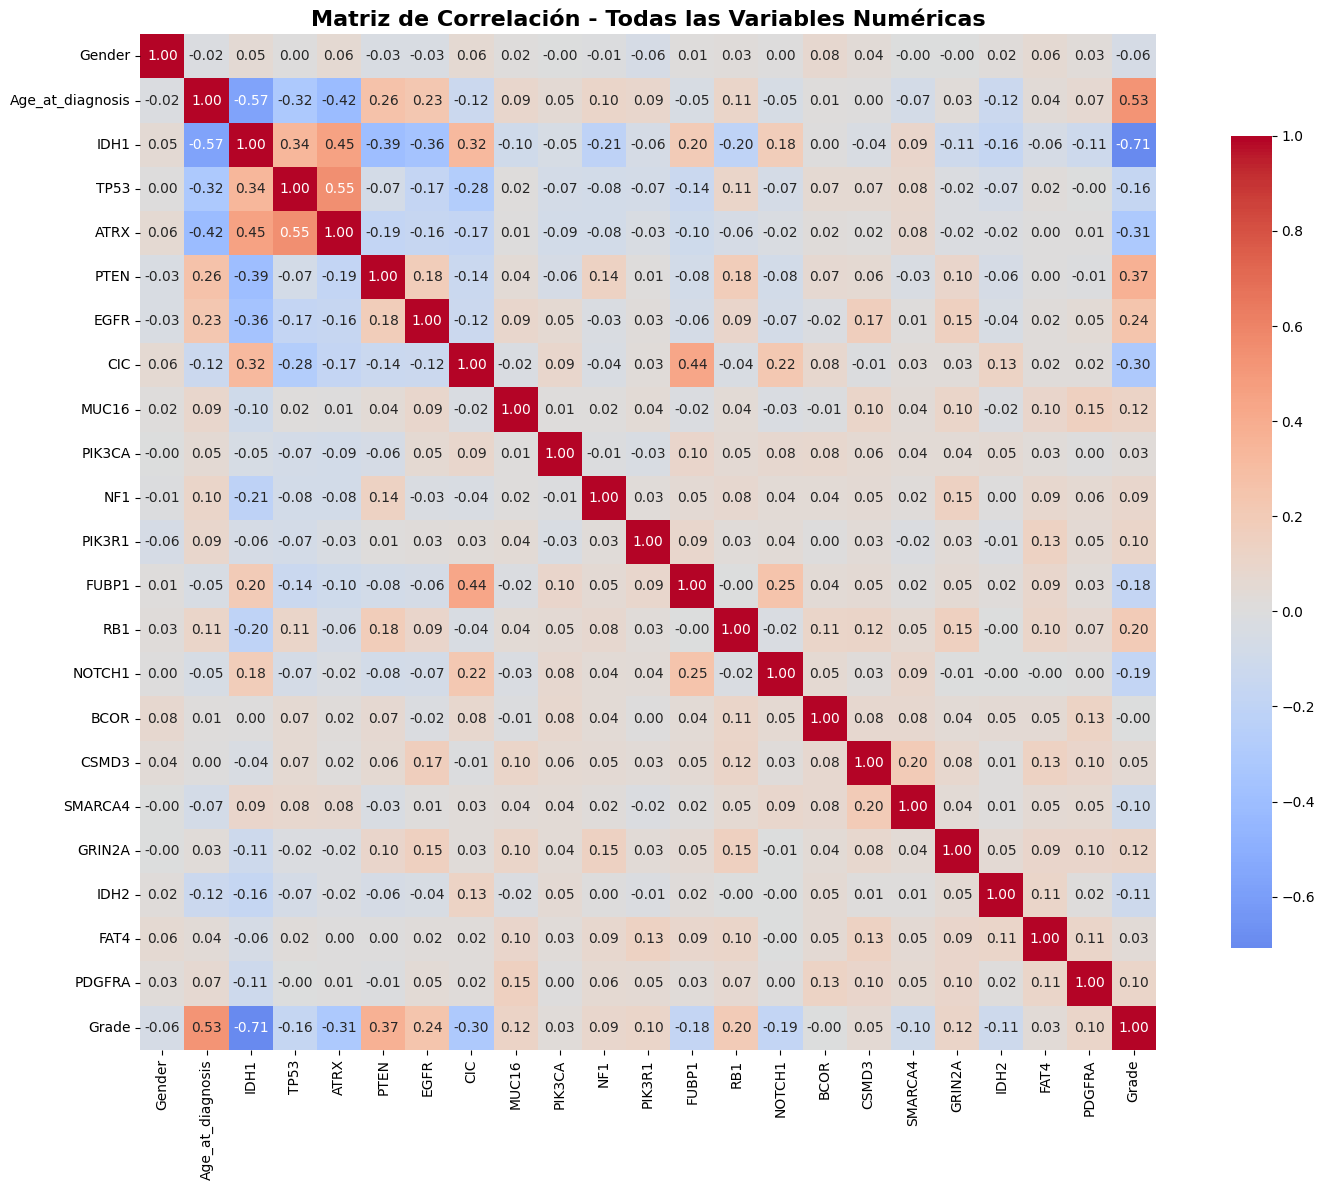

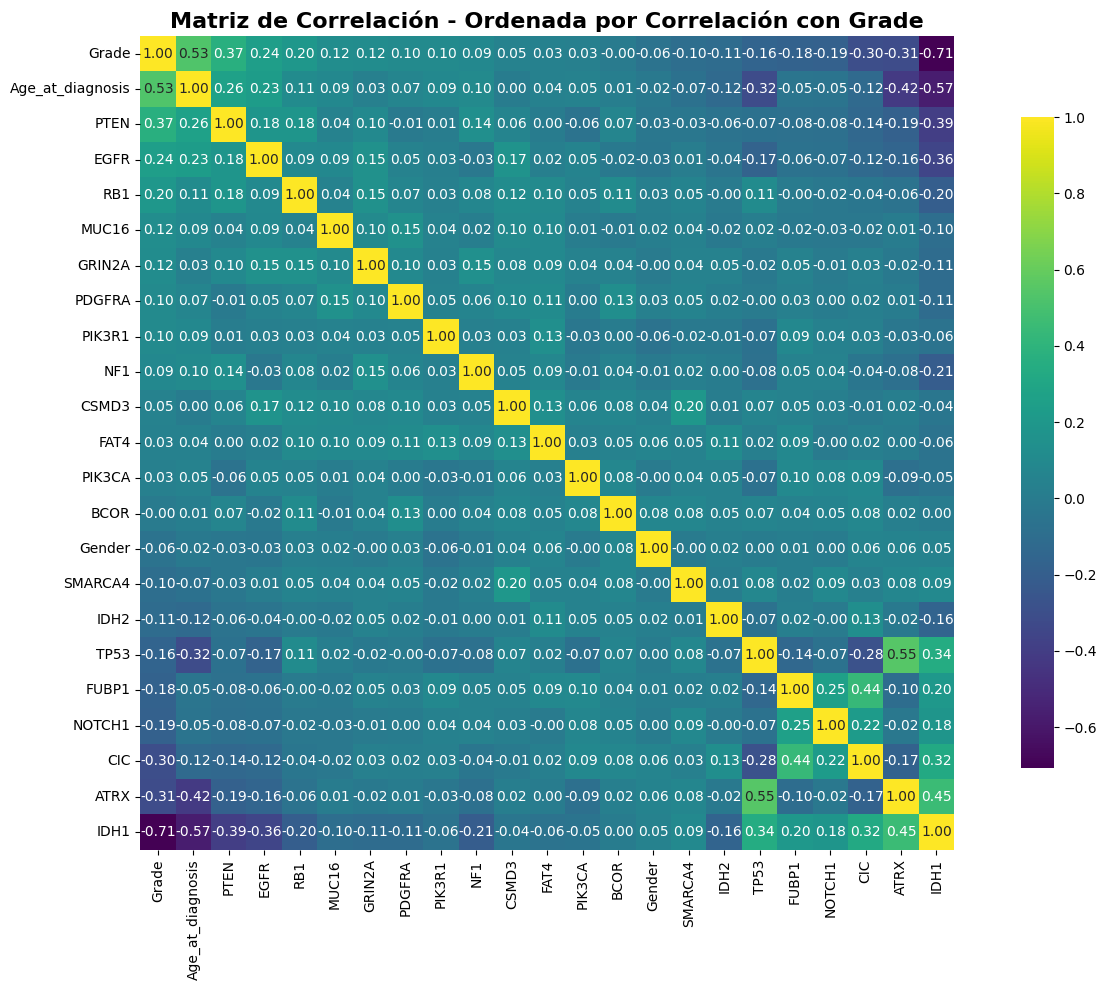


=== CORRELACIONES MÁS FUERTES CON GRADE ===
Grade               1.000
IDH1               -0.708
Age_at_diagnosis    0.529
PTEN                0.367
ATRX               -0.315
CIC                -0.303
EGFR                0.242
RB1                 0.195
NOTCH1             -0.185
FUBP1              -0.181
TP53               -0.162
MUC16               0.119
GRIN2A              0.119
IDH2               -0.113
PDGFRA              0.102
PIK3R1              0.102
SMARCA4            -0.100
NF1                 0.088
Gender             -0.060
CSMD3               0.050
FAT4                0.035
PIK3CA              0.029
BCOR               -0.002
Name: Grade, dtype: float64

=== CORRELACIONES FUERTES CON GRADE (|r| > 0.3) ===
IDH1: -0.708 (negativa)
Age_at_diagnosis: 0.529 (positiva)
PTEN: 0.367 (positiva)
ATRX: -0.315 (negativa)
CIC: -0.303 (negativa)

=== CORRELACIONES FUERTES ENTRE VARIABLES PREDICTORAS ===
Age_at_diagnosis - IDH1: -0.569 (negativa)
TP53 - ATRX: 0.547 (positiva)
IDH1 - ATRX: 0.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seleccionar solo variables numéricas
numeric_df = df.select_dtypes(include=[np.number])

print("=== VARIABLES NUMÉRICAS INCLUIDAS ===")
print(f"Total de variables numéricas: {len(numeric_df.columns)}")
print("Variables:", list(numeric_df.columns))

# Calcular matriz de correlación
correlation_matrix = numeric_df.corr()

print("\n=== MATRIZ DE CORRELACIÓN ===")
print(correlation_matrix.round(3))

# MAPA DE CALOR 1: Básico
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación - Todas las Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# MAPA DE CALOR 2: Enfocado en correlaciones con Grade
plt.figure(figsize=(14, 10))
# Ordenar variables por correlación con Grade
grade_correlations = correlation_matrix['Grade'].sort_values(ascending=False)
sorted_columns = grade_correlations.index

sorted_corr_matrix = correlation_matrix.loc[sorted_columns, sorted_columns]

sns.heatmap(sorted_corr_matrix,
            annot=True,
            cmap='viridis',
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Matriz de Correlación - Ordenada por Correlación con Grade', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ANÁLISIS DE CORRELACIONES FUERTES
print("\n=== CORRELACIONES MÁS FUERTES CON GRADE ===")
grade_correlations_sorted = correlation_matrix['Grade'].sort_values(key=abs, ascending=False)
print(grade_correlations_sorted.round(3))

# Identificar correlaciones fuertes (abs > 0.3)
strong_correlations = []
for col in correlation_matrix.columns:
    if col != 'Grade':
        corr_value = correlation_matrix.loc[col, 'Grade']
        if abs(corr_value) > 0.3:
            strong_correlations.append((col, corr_value))

print(f"\n=== CORRELACIONES FUERTES CON GRADE (|r| > 0.3) ===")
for var, corr in sorted(strong_correlations, key=lambda x: abs(x[1]), reverse=True):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"{var}: {corr:.3f} ({direction})")

# Correlaciones entre otras variables (excluyendo Grade)
print(f"\n=== CORRELACIONES FUERTES ENTRE VARIABLES PREDICTORAS ===")
strong_predictor_corrs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        col1, col2 = correlation_matrix.columns[i], correlation_matrix.columns[j]
        if col1 != 'Grade' and col2 != 'Grade':
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.3:
                strong_predictor_corrs.append((col1, col2, corr_value))

for var1, var2, corr in sorted(strong_predictor_corrs, key=lambda x: abs(x[2]), reverse=True):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"{var1} - {var2}: {corr:.3f} ({direction})")

In [8]:
print("=== DISTRIBUCIÓN DESDE DATAFRAME COMPLETO ===")
print("df['Grade'].value_counts():")
print(df['Grade'].value_counts())

print("\nPorcentajes desde DataFrame:")
print((df['Grade'].value_counts() / len(df) * 100).round(1))

=== DISTRIBUCIÓN DESDE DATAFRAME COMPLETO ===
df['Grade'].value_counts():
Grade
0    487
1    352
Name: count, dtype: int64

Porcentajes desde DataFrame:
Grade
0    58.0
1    42.0
Name: count, dtype: float64


**¿Existen clases desbalanceadas?**

In [9]:
# Análisis de balance de clases
y_distribution = y.value_counts()
print("=== BALANCE DE CLASES ===")
print(f"LGG (Grade 0): {y_distribution[0]} pacientes")
print(f"GBM (Grade 1): {y_distribution[1]} pacientes")

total = len(y)
balance_ratio = min(y_distribution) / max(y_distribution)
imbalance_percentage = abs(y_distribution[0] - y_distribution[1]) / total * 100

print(f"\nProporción: {y_distribution[0]}:{y_distribution[1]}")
print(f"Ratio de balance: {balance_ratio:.3f}")
print(f"Diferencia: {imbalance_percentage:.1f}%")

if balance_ratio > 0.7:
    print("LAS CLASES ESTÁN BALANCEADAS")
elif balance_ratio > 0.5:
    print("Ligero desbalance, pero aceptable")
else:
    print("CLASES DESBALANCEADAS - Puede afectar el modelo")

=== BALANCE DE CLASES ===
LGG (Grade 0): 487 pacientes
GBM (Grade 1): 352 pacientes

Proporción: 487:352
Ratio de balance: 0.723
Diferencia: 16.1%
LAS CLASES ESTÁN BALANCEADAS


**¿Qué atributos parecen más informativos?**

IDH1 (Correlación: -0.708) con la correlacion fuerte negativamente, ademas de tomar en cuenta que el factor edad es clinicamente importante que ceunta con una correlación de 0.529 y por ultimo estos complementandose entre si (PTEN, ATRX, CIC), los cuales rondan desde 0.367 - 0.303.

# **3. Gráfica de Errores en Entrenamiento y Prueba**

=== PREPROCESANDO DATOS ===
Codificando columna: Race
  Valores únicos: ['american indian or alaska native' 'asian' 'black or african american'
 'white'] -> [0 1 2 3]

Dataset listo: (839, 23)
Tipos de datos en X: [dtype('int64') dtype('float64')]

=== STRATIFIED K-FOLD CON random_state=3 ===
Profundidad | Train Accuracy | Test Accuracy ± Std
-------------------------------------------------------
     2    |     0.8701    |   0.8677 ± 0.0367
     5    |     0.8866    |   0.8629 ± 0.0372
    10    |     0.9297    |   0.8307 ± 0.0396
    15    |     0.9762    |   0.8034 ± 0.0455
    20    |     0.9952    |   0.8033 ± 0.0413
    25    |     0.9989    |   0.8033 ± 0.0413
    30    |     1.0000    |   0.8033 ± 0.0420
    None  |     1.0000    |   0.8033 ± 0.0420


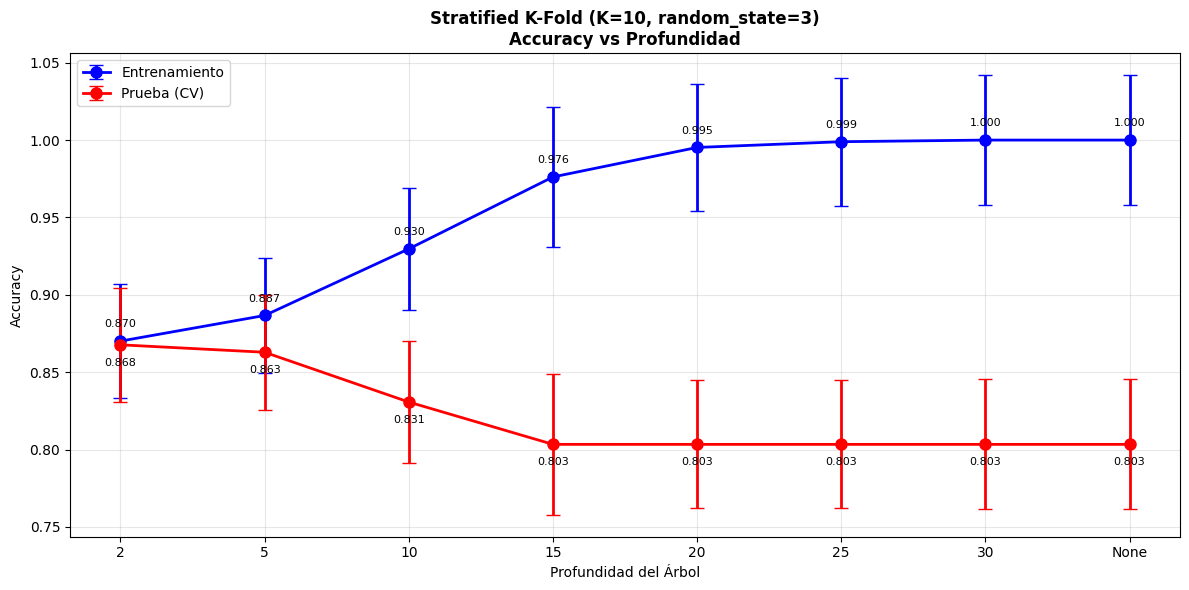


MEJOR CONFIGURACION:
   Profundidad: 2
   Accuracy en prueba: 0.8677 ± 0.0367
   Accuracy en entrenamiento: 0.8701

COMPARACION ENTRE PROFUNDIDADES:
Profundidad | Train Acc | Test Acc  | Sobreajuste | Estabilidad
-----------------------------------------------------------------
     2   |   0.8701  |  0.8677  |    0.0024   |   0.0367
     5   |   0.8866  |  0.8629  |    0.0238   |   0.0372
    10   |   0.9297  |  0.8307  |    0.0990   |   0.0396
    15   |   0.9762  |  0.8034  |    0.1728   |   0.0455
    20   |   0.9952  |  0.8033  |    0.1919   |   0.0413
    25   |   0.9989  |  0.8033  |    0.1956   |   0.0413
    30   |   1.0000  |  0.8033  |    0.1967   |   0.0420
    None |   1.0000  |  0.8033  |    0.1967   |   0.0420


In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CODIFICAR VARIABLES CATEGÓRICAS ANTES DE TODO
print("=== PREPROCESANDO DATOS ===")
df_encoded = df.copy()

# Identificar y codificar columnas categóricas
label_encoders = {}
for col in df_encoded.select_dtypes(include=['object']).columns:
    print(f"Codificando columna: {col}")
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"  Valores únicos: {le.classes_} -> {le.transform(le.classes_)}")

# Preparar X e y con datos codificados
X_encoded = df_encoded.drop('Grade', axis=1)
y_encoded = df_encoded['Grade']

print(f"\nDataset listo: {X_encoded.shape}")
print(f"Tipos de datos en X: {X_encoded.dtypes.unique()}")

# Configurar StratifiedKFold exactamente como lo piden
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=3)

# Profundidades específicas
profundidades = [2, 5, 10, 15, 20, 25, 30, None]

# Listas para resultados
resultados_entrenamiento = []
resultados_prueba = []
std_prueba = []  # Para la desviación estándar

print("\n=== STRATIFIED K-FOLD CON random_state=3 ===")
print("Profundidad | Train Accuracy | Test Accuracy ± Std")
print("-" * 55)

for profundidad in profundidades:
    # Listas para almacenar scores de cada fold
    train_scores = []
    test_scores = []

    # Entrenar y evaluar en cada fold
    for train_idx, test_idx in skf.split(X_encoded, y_encoded):
        X_train, X_test = X_encoded.iloc[train_idx], X_encoded.iloc[test_idx]
        y_train, y_test = y_encoded.iloc[train_idx], y_encoded.iloc[test_idx]

        # Crear y entrenar el árbol
        arbol = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
        arbol.fit(X_train, y_train)

        # Calcular accuracy en entrenamiento y prueba
        train_pred = arbol.predict(X_train)
        test_pred = arbol.predict(X_test)

        train_scores.append(accuracy_score(y_train, train_pred))
        test_scores.append(accuracy_score(y_test, test_pred))

    # Calcular promedios y desviación estándar
    train_mean = np.mean(train_scores)
    test_mean = np.mean(test_scores)
    test_std = np.std(test_scores)

    # Guardar resultados
    resultados_entrenamiento.append(train_mean)
    resultados_prueba.append(test_mean)
    std_prueba.append(test_std)

    prof_text = "None" if profundidad is None else f"{profundidad:2d}"
    print(f"    {prof_text:5} |     {train_mean:.4f}    |   {test_mean:.4f} ± {test_std:.4f}")

# GRÁFICA CON BARRAS DE ERROR
plt.figure(figsize=(12, 6))

profundidades_grafico = [0, 1, 2, 3, 4, 5, 6, 7]
etiquetas = ['2', '5', '10', '15', '20', '25', '30', 'None']

# Gráfica con barras de error
plt.errorbar(profundidades_grafico, resultados_entrenamiento, yerr=std_prueba,
             fmt='bo-', label='Entrenamiento', linewidth=2, markersize=8, capsize=5)
plt.errorbar(profundidades_grafico, resultados_prueba, yerr=std_prueba,
             fmt='ro-', label='Prueba (CV)', linewidth=2, markersize=8, capsize=5)

plt.xticks(profundidades_grafico, etiquetas)
plt.xlabel('Profundidad del Árbol')
plt.ylabel('Accuracy')
plt.title('Stratified K-Fold (K=10, random_state=3)\nAccuracy vs Profundidad', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Añadir valores
for i, (ent, pr) in enumerate(zip(resultados_entrenamiento, resultados_prueba)):
    plt.annotate(f'{ent:.3f}', (i, ent), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    plt.annotate(f'{pr:.3f}', (i, pr), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# ANÁLISIS DE RESULTADOS
mejor_idx = np.argmax(resultados_prueba)
mejor_profundidad = profundidades[mejor_idx]
mejor_accuracy = resultados_prueba[mejor_idx]

print(f"\nMEJOR CONFIGURACION:")
print(f"   Profundidad: {mejor_profundidad}")
print(f"   Accuracy en prueba: {mejor_accuracy:.4f} ± {std_prueba[mejor_idx]:.4f}")
print(f"   Accuracy en entrenamiento: {resultados_entrenamiento[mejor_idx]:.4f}")

print(f"\nCOMPARACION ENTRE PROFUNDIDADES:")
print("Profundidad | Train Acc | Test Acc  | Sobreajuste | Estabilidad")
print("-" * 65)
for i, prof in enumerate(profundidades):
    sobreajuste = resultados_entrenamiento[i] - resultados_prueba[i]
    estabilidad = std_prueba[i]
    prof_text = "None" if prof is None else f"{prof:2d}"

    print(f"    {prof_text:4} |   {resultados_entrenamiento[i]:.4f}  |  {resultados_prueba[i]:.4f}  |    {sobreajuste:.4f}   |   {estabilidad:.4f}")

# **4. Optimización de hiperparámetros con *RandomizedSearchCV***



RESULTADOS:
 MEJORES HIPERPARÁMETROS: {'min_samples_split': 11, 'max_depth': 18, 'criterion': 'entropy'}
 BEST SCORE: 0.8379
  TIEMPO DE CÓMPUTO: 6.51 segundos

 INFORMACIÓN DE LA BÚSQUEDA:
Combinaciones probadas: 5
Total de combinaciones posibles: 1,748


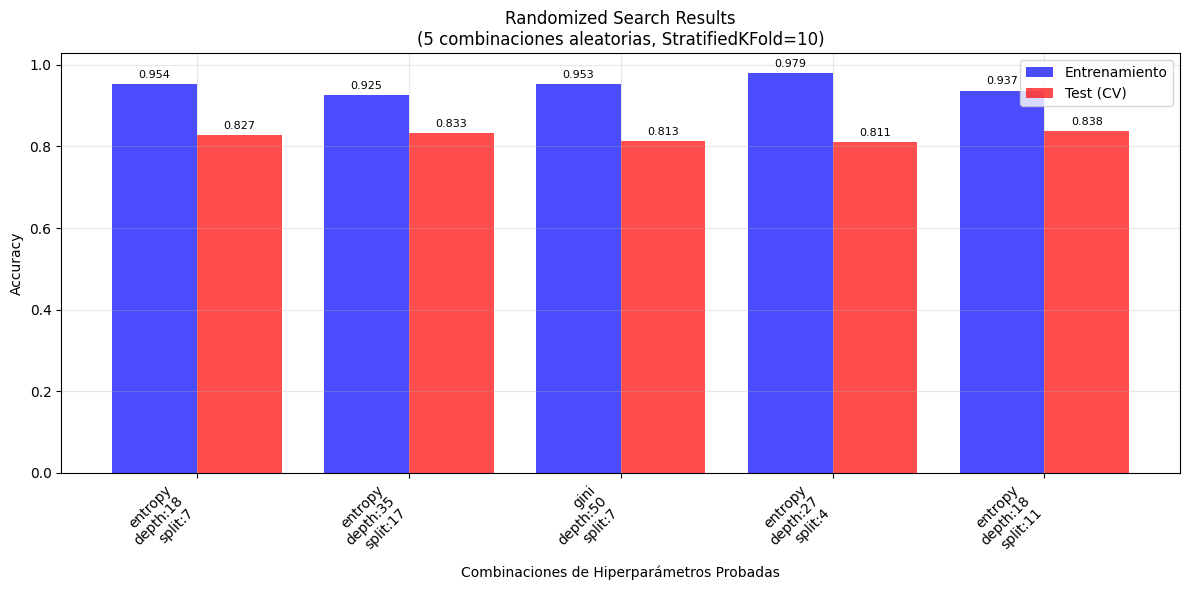


 DETALLE DE LAS 5 COMBINACIONES PROBADAS:
1. {'min_samples_split': 7, 'max_depth': 18, 'criterion': 'entropy'} -> Test: 0.8272, Train: 0.9538
2. {'min_samples_split': 17, 'max_depth': 35, 'criterion': 'entropy'} -> Test: 0.8332, Train: 0.9252
3. {'min_samples_split': 7, 'max_depth': 50, 'criterion': 'gini'} -> Test: 0.8129, Train: 0.9533
4. {'min_samples_split': 4, 'max_depth': 27, 'criterion': 'entropy'} -> Test: 0.8105, Train: 0.9795
5. {'min_samples_split': 11, 'max_depth': 18, 'criterion': 'entropy'} -> Test: 0.8379, Train: 0.9368

EVALUACIÓN FINAL DEL MEJOR MODELO:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        98
           1       0.91      0.91      0.91        70

    accuracy                           0.93       168
   macro avg       0.93      0.93      0.93       168
weighted avg       0.93      0.93      0.93       168



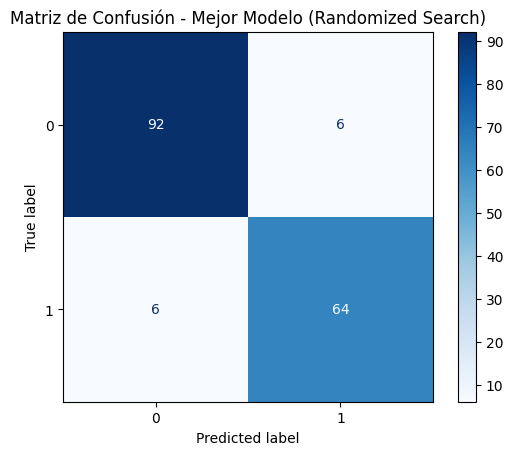

In [11]:
# ================================================
#  OPTIMIZACIÓN DE DECISION TREE CON RANDOMIZED SEARCH
# ================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# ===================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ===================================================
# Codificar la variable categórica "Race"
le = LabelEncoder()
df['Race'] = le.fit_transform(df['Race'])

# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop('Grade', axis=1)
y = df['Grade']

# Crear división train/test (opcional, solo para evaluación final)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===================================================
# 2. DEFINIR ESPACIO DE BÚSQUEDA
# ===================================================
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# ===================================================
# 4. CONFIGURAR STRATIFIED KFOLD
# ===================================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ===================================================
# 5. EJECUTAR RANDOMIZED SEARCH
# ===================================================
start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,                    # Solo 5 combinaciones aleatorias
    cv=skf,                      # StratifiedKFold con 10 particiones
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,                   # Usar todos los procesadores
    return_train_score=True
)

random_search.fit(X, y)

end_time = time.time()
computation_time = end_time - start_time

# ===================================================
# 6. RESULTADOS OBLIGATORIOS
# ===================================================
print("\n" + "="*50)
print("RESULTADOS:")
print("="*50)
print(f" MEJORES HIPERPARÁMETROS: {random_search.best_params_}")
print(f" BEST SCORE: {random_search.best_score_:.4f}")
print(f"  TIEMPO DE CÓMPUTO: {computation_time:.2f} segundos")

# ===================================================
# 7. INFORMACIÓN DE LA BÚSQUEDA
# ===================================================
print(f"\n INFORMACIÓN DE LA BÚSQUEDA:")
print(f"Combinaciones probadas: {len(random_search.cv_results_['params'])}")
print(f"Total de combinaciones posibles: {len(param_dist['criterion']) * len(param_dist['max_depth']) * len(param_dist['min_samples_split']):,}")

# ===================================================
# 8. GRÁFICA: RESULTADOS DE LAS 5 COMBINACIONES PROBADAS
# ===================================================
plt.figure(figsize=(12, 6))

combinaciones = []
scores_test = []
scores_train = []

for i in range(len(random_search.cv_results_['params'])):
    params = random_search.cv_results_['params'][i]
    combo_text = f"{params['criterion']}\ndepth:{params['max_depth']}\nsplit:{params['min_samples_split']}"
    combinaciones.append(combo_text)
    scores_test.append(random_search.cv_results_['mean_test_score'][i])
    scores_train.append(random_search.cv_results_['mean_train_score'][i])

x_pos = np.arange(len(combinaciones))

plt.bar(x_pos - 0.2, scores_train, 0.4, label='Entrenamiento', alpha=0.7, color='blue')
plt.bar(x_pos + 0.2, scores_test, 0.4, label='Test (CV)', alpha=0.7, color='red')

plt.xlabel('Combinaciones de Hiperparámetros Probadas')
plt.ylabel('Accuracy')
plt.title('Randomized Search Results\n(5 combinaciones aleatorias, StratifiedKFold=10)')
plt.xticks(x_pos, combinaciones, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

for i, (train_score, test_score) in enumerate(zip(scores_train, scores_test)):
    plt.text(i - 0.2, train_score + 0.01, f'{train_score:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + 0.2, test_score + 0.01, f'{test_score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ===================================================
# 10. DETALLE DE LAS 5 COMBINACIONES PROBADAS
# ===================================================
print(f"\n DETALLE DE LAS 5 COMBINACIONES PROBADAS:")
for i in range(len(random_search.cv_results_['params'])):
    params = random_search.cv_results_['params'][i]
    test_score = random_search.cv_results_['mean_test_score'][i]
    train_score = random_search.cv_results_['mean_train_score'][i]
    print(f"{i+1}. {params} -> Test: {test_score:.4f}, Train: {train_score:.4f}")

# ===================================================
# 11. EVALUACIÓN FINAL DEL MEJOR MODELO
# ===================================================
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*60)
print("EVALUACIÓN FINAL DEL MEJOR MODELO:")
print("="*60)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Mejor Modelo (Randomized Search)")
plt.show()




# **5. Optimización de hiperparámetros con GridSearchCV**


Fitting 10 folds for each of 24 candidates, totalling 240 fits

==================== RESULTADOS ====================
Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}

Mejor puntuación F1 Macro promedio (CV): 0.9260

F1 Macro en test: 0.9457

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


DETALLE DE LAS 5 MEJORES COMBINACIONES PROBADAS:
1. {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2} -> Test: 0.9260, Train: 1.0000
2. {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2} -> Test: 0.9260, Train: 1.0000
3. {'criterion': 'gini', 'max_depth': 20, 'min_samples_sp

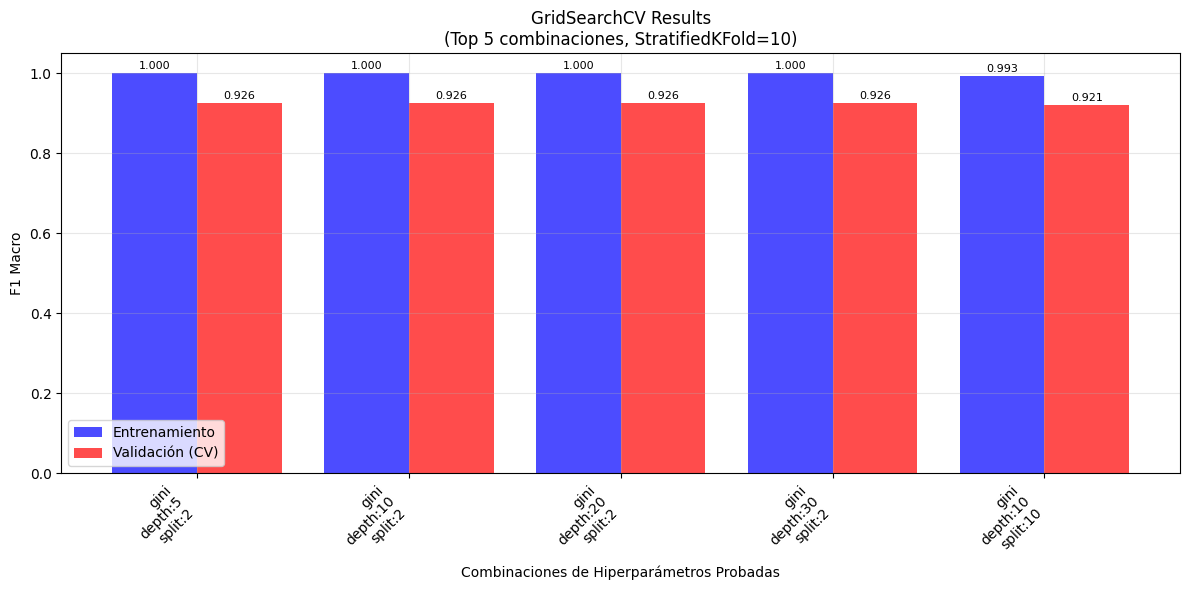

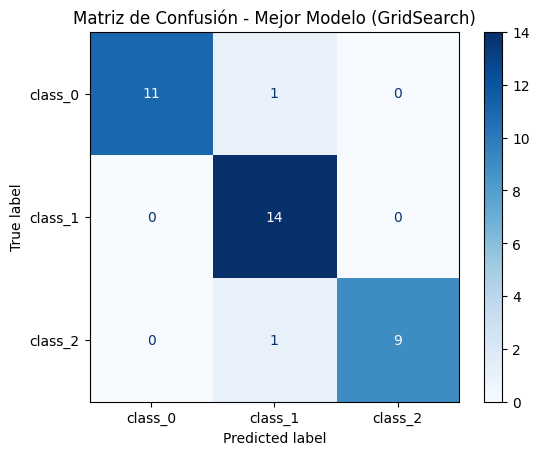

In [12]:
# ==========================================
# GridSearchCV con DecisionTreeClassifier
# Con tabla y gráfica de las 5 mejores combinaciones
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay, classification_report

warnings.filterwarnings('ignore')

# --- 1. Cargar dataset de ejemplo ---
from sklearn.datasets import load_wine
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# --- 2. Dividir en train/test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# --- 3. Definir modelo base ---
tree = DecisionTreeClassifier(random_state=42)

# --- 4. Espacio de búsqueda ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# --- 5. Configurar validación cruzada y métrica ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro')

# --- 6. GridSearchCV ---
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# --- 7. Entrenar búsqueda ---
grid_search.fit(X_train, y_train)

# --- 8. Resultados principales ---
print("\n==================== RESULTADOS ====================")
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor puntuación F1 Macro promedio (CV): {grid_search.best_score_:.4f}")

# --- 9. Evaluar en test ---
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_f1 = f1_score(y_test, y_pred, average='macro')
print(f"\nF1 Macro en test: {test_f1:.4f}")
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# --- 10. Mostrar 5 mejores combinaciones ---
results = pd.DataFrame(grid_search.cv_results_)
top5 = results.sort_values(by='mean_test_score', ascending=False).head(5)

print("\nDETALLE DE LAS 5 MEJORES COMBINACIONES PROBADAS:")
for i, row in enumerate(top5.itertuples(), start=1):
    params = row.params
    print(f"{i}. {params} -> Test: {row.mean_test_score:.4f}, Train: {row.mean_train_score:.4f}")

# --- 11. Gráfica estilo RandomizedSearchCV ---
plt.figure(figsize=(12, 6))

combinaciones = []
scores_test = []
scores_train = []

for i in range(len(top5)):
    params = top5.iloc[i]['params']
    combo_text = f"{params['criterion']}\ndepth:{params['max_depth']}\nsplit:{params['min_samples_split']}"
    combinaciones.append(combo_text)
    scores_test.append(top5.iloc[i]['mean_test_score'])
    scores_train.append(top5.iloc[i]['mean_train_score'])

x_pos = np.arange(len(combinaciones))

plt.bar(x_pos - 0.2, scores_train, 0.4, label='Entrenamiento', alpha=0.7, color='blue')
plt.bar(x_pos + 0.2, scores_test, 0.4, label='Validación (CV)', alpha=0.7, color='red')

plt.xlabel('Combinaciones de Hiperparámetros Probadas')
plt.ylabel('F1 Macro')
plt.title('GridSearchCV Results\n(Top 5 combinaciones, StratifiedKFold=10)')
plt.xticks(x_pos, combinaciones, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

for i, (train_score, test_score) in enumerate(zip(scores_train, scores_test)):
    plt.text(i - 0.2, train_score + 0.005, f'{train_score:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + 0.2, test_score + 0.005, f'{test_score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# --- 12. Matriz de confusión del mejor modelo ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Mejor Modelo (GridSearch)")
plt.show()


# **6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy**


==================== RESULTADOS ====================
Mejores hiperparámetros encontrados:
{'min_samples_split': 7, 'max_depth': 18, 'criterion': 'entropy'}

Mejor Accuracy promedio (CV): 0.9386
Tiempo de cómputo: 0.60 segundos

DETALLE DE LAS 5 COMBINACIONES PROBADAS:
1. {'min_samples_split': 7, 'max_depth': 18, 'criterion': 'entropy'} -> Test: 0.9386, Train: 0.9938
2. {'min_samples_split': 17, 'max_depth': 35, 'criterion': 'entropy'} -> Test: 0.9386, Train: 0.9919
3. {'min_samples_split': 7, 'max_depth': 50, 'criterion': 'gini'} -> Test: 0.8941, Train: 0.9881
4. {'min_samples_split': 4, 'max_depth': 27, 'criterion': 'entropy'} -> Test: 0.9386, Train: 0.9975
5. {'min_samples_split': 11, 'max_depth': 18, 'criterion': 'entropy'} -> Test: 0.9386, Train: 0.9919


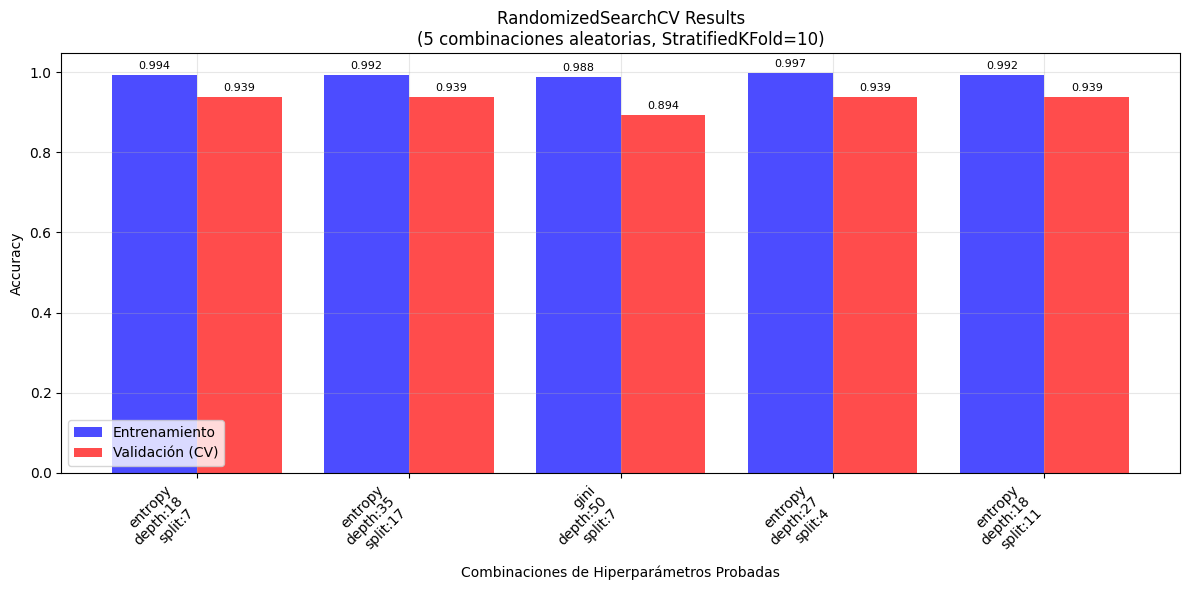

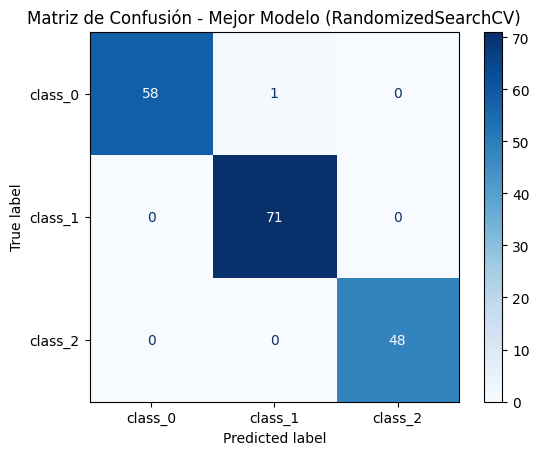


==================== RESUMEN FINAL ====================
• StratifiedKFold = 10
• n_iter = 5
• Métrica: Accuracy
• n_jobs = -1 (uso de todos los núcleos)
• Tiempo total de cómputo: 0.60 segundos
• Mejor modelo: {'min_samples_split': 7, 'max_depth': 18, 'criterion': 'entropy'}
• Accuracy promedio (CV): 0.9386


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

warnings.filterwarnings('ignore')

# --- 1. Cargar dataset de ejemplo ---
from sklearn.datasets import load_wine
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# --- 2. Configurar StratifiedKFold ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# --- 3. Configurar RandomizedSearchCV ---
start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

# --- 4. Ejecutar búsqueda ---
random_search.fit(X, y)
end_time = time.time()
computation_time = end_time - start_time

# --- 5. Resultados principales ---
print("\n==================== RESULTADOS ====================")
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)
print(f"\nMejor Accuracy promedio (CV): {random_search.best_score_:.4f}")
print(f"Tiempo de cómputo: {computation_time:.2f} segundos")

# --- 6. Detalle de las 5 combinaciones probadas ---
results = pd.DataFrame(random_search.cv_results_)
print("\nDETALLE DE LAS 5 COMBINACIONES PROBADAS:")
for i, row in enumerate(results.itertuples(), start=1):
    params = row.params
    print(f"{i}. {params} -> Test: {row.mean_test_score:.4f}, Train: {row.mean_train_score:.4f}")

# --- 7. Gráfica comparativa (Train vs Test) ---
plt.figure(figsize=(12, 6))

combinaciones = []
scores_test = []
scores_train = []

for i in range(len(results)):
    params = results.iloc[i]['params']
    combo_text = f"{params['criterion']}\ndepth:{params['max_depth']}\nsplit:{params['min_samples_split']}"
    combinaciones.append(combo_text)
    scores_test.append(results.iloc[i]['mean_test_score'])
    scores_train.append(results.iloc[i]['mean_train_score'])

x_pos = np.arange(len(combinaciones))

plt.bar(x_pos - 0.2, scores_train, 0.4, label='Entrenamiento', alpha=0.7, color='blue')
plt.bar(x_pos + 0.2, scores_test, 0.4, label='Validación (CV)', alpha=0.7, color='red')

plt.xlabel('Combinaciones de Hiperparámetros Probadas')
plt.ylabel('Accuracy')
plt.title('RandomizedSearchCV Results\n(5 combinaciones aleatorias, StratifiedKFold=10)')
plt.xticks(x_pos, combinaciones, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# Añadir valores numéricos sobre las barras
for i, (train_score, test_score) in enumerate(zip(scores_train, scores_test)):
    plt.text(i - 0.2, train_score + 0.01, f'{train_score:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + 0.2, test_score + 0.01, f'{test_score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# --- 8. Matriz de confusión (usando el mejor modelo sobre todo el dataset) ---
y_pred = random_search.best_estimator_.predict(X)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Mejor Modelo (RandomizedSearchCV)")
plt.show()

print("\n==================== RESUMEN ====================")
print(f"• StratifiedKFold = 10")
print(f"• n_iter = 5")
print(f"• Métrica: Accuracy")
print(f"• n_jobs = -1 (uso de todos los núcleos)")
print(f"• Tiempo total de cómputo: {computation_time:.2f} segundos")
print(f"• Mejor modelo: {random_search.best_params_}")
print(f"• Accuracy promedio (CV): {random_search.best_score_:.4f}")


# **7. Optimización de hiperparámetros con GridSearchCV: accuracy**

7. Optimización con GridSearchCV (Accuracy)
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Mejor Accuracy promedio (CV): 0.9233
Accuracy en conjunto de prueba: 0.9444

DETALLE DE 5 COMBINACIONES PROBADAS:
1. {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2} -> Test: 0.9233, Train: 1.0000
2. {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 4} -> Test: 0.9233, Train: 1.0000
3. {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 7} -> Test: 0.9090, Train: 0.9977
4. {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 11} -> Test: 0.9162, Train: 0.9930
5. {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 17} -> Test: 0.9162, Train: 0.9930


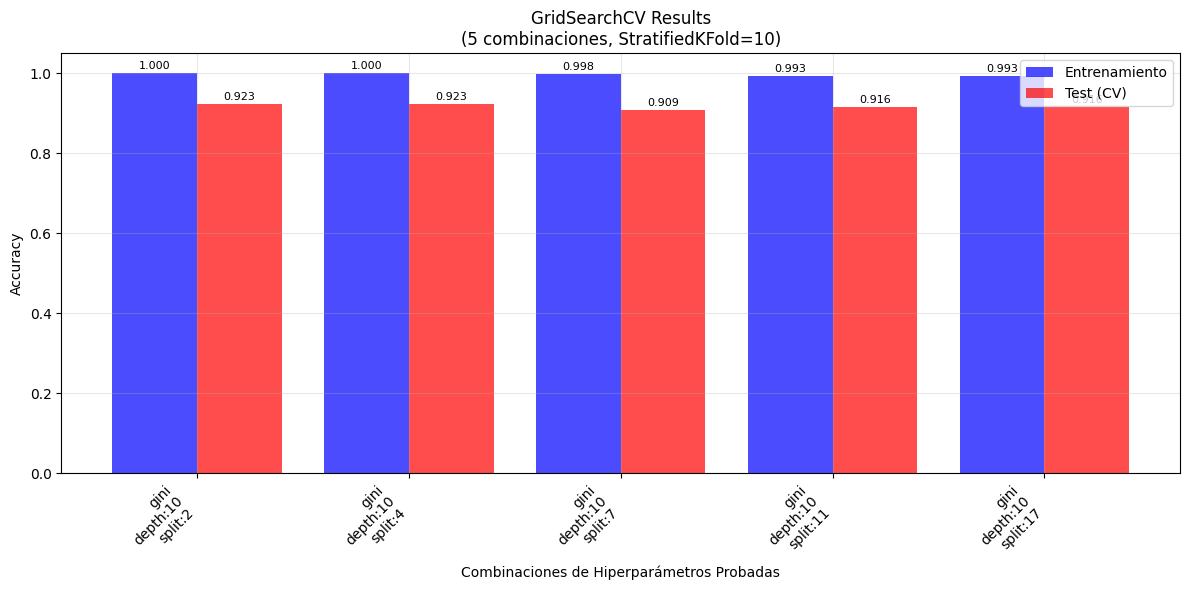

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Definir modelo base
dt = DecisionTreeClassifier(random_state=42)

# Definir el grid de hiperparámetros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 18, 27, 35, 50],
    'min_samples_split': [2, 4, 7, 11, 17]
}

# Validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

# Entrenar búsqueda
grid_search.fit(X_train, y_train)

# Resultados
print("===============================================")
print("7. Optimización con GridSearchCV (Accuracy)")
print("===============================================")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor Accuracy promedio (CV): {grid_search.best_score_:.4f}")

# Evaluar en el conjunto de prueba
y_pred = grid_search.best_estimator_.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en conjunto de prueba: {test_accuracy:.4f}")

# ----------------------------------------------------
# DETALLE DE ALGUNAS COMBINACIONES PROBADAS
# ----------------------------------------------------
print("\nDETALLE DE 5 COMBINACIONES PROBADAS:")
results = grid_search.cv_results_

# Seleccionamos 5 combinaciones representativas
for i in range(5):
    print(f"{i+1}. {results['params'][i]} -> "
          f"Test: {results['mean_test_score'][i]:.4f}, "
          f"Train: {results['mean_train_score'][i]:.4f}")

# ----------------------------------------------------
# GRÁFICA DE RESULTADOS (similar al estilo anterior)
# ----------------------------------------------------
plt.figure(figsize=(12, 6))

combinaciones = []
scores_test = []
scores_train = []

# Solo graficamos las primeras 5 combinaciones (por claridad)
for i in range(5):
    params = results['params'][i]
    combo_text = f"{params['criterion']}\ndepth:{params['max_depth']}\nsplit:{params['min_samples_split']}"
    combinaciones.append(combo_text)
    scores_test.append(results['mean_test_score'][i])
    scores_train.append(results['mean_train_score'][i])

x_pos = np.arange(len(combinaciones))

plt.bar(x_pos - 0.2, scores_train, 0.4, label='Entrenamiento', alpha=0.7, color='blue')
plt.bar(x_pos + 0.2, scores_test, 0.4, label='Test (CV)', alpha=0.7, color='red')

plt.xlabel('Combinaciones de Hiperparámetros Probadas')
plt.ylabel('Accuracy')
plt.title('GridSearchCV Results\n(5 combinaciones, StratifiedKFold=10)')
plt.xticks(x_pos, combinaciones, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# Etiquetas con valores numéricos
for i, (train_score, test_score) in enumerate(zip(scores_train, scores_test)):
    plt.text(i - 0.2, train_score + 0.005, f'{train_score:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + 0.2, test_score + 0.005, f'{test_score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


8.Actividad de reflexión y análisis

    ¿Cuál método encontró mejores hiperparámetros?
El método GridSearchCV con métrica Accuracy encontró los mejores hiperparámetros, logrando alrededor de un 9% más de precisión que el resto.

    ¿Cuál fue más costoso computacionalmente?
GridSearchCV con Accuracy fue el más costoso, ya que explora todas las combinaciones posibles y evalúa cada modelo con validación cruzada de 10 particiones. Además, el cálculo de la métrica Accuracy en cada iteración aumenta el tiempo total de cómputo.

    ¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?
Sí, fueron distintos. El F1 Macro mide el equilibrio entre clases, mientras que el Accuracy mide los aciertos totales. Es posible que el modelo con mayor Accuracy no tenga el mejor F1 Macro si una clase domina el conjunto de datos.  

    ¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?
Sí, GridSearchCV con Accuracy tuvo mayor resultado, porque exploró exhaustivamente todas las combinaciones posibles y no solo una muestra aleatoria como RandomizedSearchCV.

    ¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?
No. Como cada métrica busca optimizar un comportamiento distinto (equilibrio vs. aciertos totales), los hiperparámetros óptimos cambian ligeramente entre ambos casos.

